# 📊 DỰ ÁN 1 — XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

**Notebook 03/07 — Data Cleaning (Làm sạch dữ liệu)**

---

**🎯 Mục tiêu:** Làm sạch dữ liệu: xử lý giá trị thiếu, giá trị bất thường/ngoại lai, chuẩn hóa kiểu dữ liệu và loại bỏ các cột không sử dụng.

**📥 Input:** Dữ liệu từ PostgreSQL (notebook 02) hoặc `data/raw/application_train.csv`

**📤 Output:** `data/processed/application_train_clean.csv` và `data/processed/application_test_clean.csv` — bộ dữ liệu đã làm sạch.

**🔗 Pipeline:** 02. PostgreSQL Pipeline → **03. Data Cleaning** → 04. EDA & Visualization

## ⚙️ Chuẩn bị trước khi chạy (BẮT BUỘC cho mỗi thành viên)

Notebook này đọc **thẳng từ file CSV thô** trong `data/raw/` — **KHÔNG** cần PostgreSQL, **KHÔNG** cần `.env`, **KHÔNG** cần chạy notebook 02 trước. Sau khi `git pull`, cần chuẩn bị **1 lần** (các thứ này KHÔNG nằm trong git — đã `.gitignore`):

1. **Cài thư viện Python:**
   ```
   pip install -r requirements.txt
   ```
2. **Tải bộ dữ liệu Home Credit Default Risk (Kaggle)** và đặt file CSV vào `data/raw/` — notebook này dùng `application_train.csv` và `application_test.csv` (tải chung một lần với các notebook khác).

> 💡 **Chỉ cần ĐỌC kết quả thì không phải chạy lại.** Notebook đã được chạy sẵn trên **toàn bộ dữ liệu** và kết quả được lưu ngay trong file — cứ mở lên đọc. Chỉ chạy lại khi bạn sửa code, hoặc cần sinh lại file `*_clean.csv` trên máy mình (ví dụ để làm notebook 06).

**Về cờ `DEBUG` (ô cấu hình ở mục 1):**
- `DEBUG = False` (mặc định) → làm sạch **toàn bộ** dữ liệu: 307.511 dòng train / 48.744 dòng test. Đây là chế độ dùng cho kết quả chính thức.
- `DEBUG = True` → chỉ nạp **mẫu 15.000 dòng train / 5.000 dòng test** để chạy thử nhanh, nhẹ RAM. File `*_clean.csv` xuất ra khi đó là **dữ liệu MẪU**, đừng dùng để huấn luyện mô hình thật.
- **⚠️ Quan trọng — vị trí trong pipeline:** NB03 là bước ĐẦU của chuỗi *làm sạch → đặc trưng*. Notebook 05 (Feature Engineering) sẽ đọc lại 2 file `*_clean.csv` mà NB03 xuất ra. Nếu chạy lại thì **phải chạy NB03 trước, rồi mới tới NB05**, và giữ cờ `DEBUG` giống nhau ở cả hai.
- **⚠️ RAM:** chạy `DEBUG = False` cần máy còn trống tối thiểu ~4 GB RAM (NB05 cần nhiều hơn vì phải gom các bảng phụ hàng chục triệu dòng). Máy yếu thì bật `DEBUG = True` để chạy thử.

Xong các bước trên → **Kernel → Restart & Run All**.

---

## 1. Chuẩn bị môi trường & Cấu hình

Thiết lập các thư viện cần thiết, đường dẫn dữ liệu và các hàm tiện ích hỗ trợ tối ưu hóa bộ nhớ.

In [1]:
import os
import gc
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ⚠️ KHÔNG dùng warnings.filterwarnings("ignore") cho TẤT CẢ cảnh báo.
# Lý do: nó từng nuốt mất ChainedAssignmentError của pandas 3 (Copy-on-Write),
# khiến bước thay 365243 -> NaN và XNA -> 'F' thất bại ÂM THẦM mà không ai biết.
# Chỉ tắt các cảnh báo "ồn ào" KHÔNG liên quan tới tính đúng đắn của dữ liệu.
# (ChainedAssignmentError kế thừa thẳng từ Warning nên vẫn hiện ra bình thường.)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

# Cấu hình hiển thị
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Thiết lập đường dẫn dữ liệu
DATA_RAW = next((p for p in [Path("data/raw"), Path("../data/raw")] if p.exists()), Path("../data/raw"))
DATA_PROCESSED = next((p for p in [Path("data/processed"), Path("../data/processed")] if p.exists()), Path("../data/processed"))
os.makedirs(DATA_PROCESSED, exist_ok=True)

# DEBUG = False -> làm sạch TOÀN BỘ dữ liệu (307.511 dòng train / 48.744 dòng test).
# Đổi sang True nếu máy yếu RAM và chỉ cần chạy thử nhanh trên mẫu 15.000 / 5.000 dòng.
DEBUG = False

print(f"Thư mục dữ liệu thô: {DATA_RAW.resolve()}")
print(f"Thư mục dữ liệu đầu ra: {DATA_PROCESSED.resolve()}")
print(f"DEBUG mode: {DEBUG}")

Thư mục dữ liệu thô: D:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\data\raw
Thư mục dữ liệu đầu ra: D:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\data\processed
DEBUG mode: False


### 1.1. Hàm tiện ích tối ưu hóa bộ nhớ

Định nghĩa hàm `reduce_mem_usage` giúp tối ưu dung lượng RAM bằng cách chuyển đổi kiểu dữ liệu số về mức nhỏ nhất có thể mà không làm mất thông tin.

In [2]:
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if pd.isna(c_min) or pd.isna(c_max):
                continue
            if pd.api.types.is_integer_dtype(df[col]):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].astype('category')
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"RAM giảm từ {start_mem:,.2f} MB xuống {end_mem:,.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)")
    return df

## 2. Nạp dữ liệu đơn chính

Chúng ta sẽ nạp hai bảng đơn chính `application_train` và `application_test` từ thư mục dữ liệu thô.

In [3]:
if DEBUG:
    print("Đang nạp mẫu dữ liệu (nrows=15000 train / 5000 test) ở chế độ DEBUG...")
    train = pd.read_csv(DATA_RAW / "application_train.csv", nrows=15000)
    test = pd.read_csv(DATA_RAW / "application_test.csv", nrows=5000)
else:
    print("Đang nạp toàn bộ dữ liệu...")
    train = pd.read_csv(DATA_RAW / "application_train.csv")
    test = pd.read_csv(DATA_RAW / "application_test.csv")

print(f"Kích thước tập Train: {train.shape}")
print(f"Kích thước tập Test: {test.shape}")

Đang nạp toàn bộ dữ liệu...


Kích thước tập Train: (307511, 122)
Kích thước tập Test: (48744, 121)


**Nhận xét:** Bảng đơn chính chứa thông tin của khách hàng vay vốn. Tập Train có 122 cột (bao gồm cả biến mục tiêu `TARGET`), trong khi tập Test có 121 cột (không có cột `TARGET`). Việc tải dữ liệu hoàn tất đúng mục tiêu.

## 3. Phân tích & Xử lý Giá trị bất thường/ngoại lai (Outliers & Anomalies)

Chúng ta sẽ kiểm tra các cột số có thể chứa các giá trị bất thường hoặc phi lý.

In [4]:
# 3.1. Phân tích DAYS_EMPLOYED
print("Thống kê mô tả DAYS_EMPLOYED:")
print(train['DAYS_EMPLOYED'].describe())
anom_count = (train['DAYS_EMPLOYED'] == 365243).sum()
print(f"\nSố dòng có giá trị DAYS_EMPLOYED = 365243 trong Train: {anom_count} ({anom_count / len(train) * 100:.2f}%)")

Thống kê mô tả DAYS_EMPLOYED:
count   307,511.0000
mean     63,815.0459
std     141,275.7665
min     -17,912.0000
25%      -2,760.0000
50%      -1,213.0000
75%        -289.0000
max     365,243.0000
Name: DAYS_EMPLOYED, dtype: float64

Số dòng có giá trị DAYS_EMPLOYED = 365243 trong Train: 55374 (18.01%)


**Nhận xét:** Giá trị `DAYS_EMPLOYED = 365243` tương đương khoảng 1000 năm, đây là giá trị bất thường biểu thị dữ liệu bị khuyết hoặc khách hàng đang thất nghiệp/không có thông tin việc làm. Chúng ta sẽ thay thế giá trị này bằng `NaN` và tạo thêm cột cờ hiệu `DAYS_EMPLOYED_ANOM` để giữ lại thông tin này cho mô hình.

In [5]:
# Xử lý DAYS_EMPLOYED trên cả Train và Test
for df in [train, test]:
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    # Dùng phép GÁN, KHÔNG dùng df['cột'].replace(..., inplace=True):
    # chained inplace không bao giờ ghi được vào df gốc dưới Copy-on-Write (pandas >= 3).
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # Chuyển các cột biểu diễn Ngày âm sang dạng Dương (Positive)
    days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']
    for col in days_cols:
        if col in df.columns:
            df[col] = df[col].abs()

# Kiểm chứng bắt buộc: nếu việc thay thế thất bại thì dừng ngay, không để lọt xuống bước sau
for ten, df in [("Train", train), ("Test", test)]:
    con_lai = (df['DAYS_EMPLOYED'] == 365243).sum()
    assert con_lai == 0, f"{ten}: vẫn còn {con_lai} dòng DAYS_EMPLOYED = 365243 — việc thay thế đã THẤT BẠI!"
print("✅ Kiểm chứng đạt: không còn dòng nào có DAYS_EMPLOYED = 365243 (đã thay bằng NaN).")

print("\nDAYS_EMPLOYED sau khi xử lý (Train):")
print(train['DAYS_EMPLOYED'].describe())

✅ Kiểm chứng đạt: không còn dòng nào có DAYS_EMPLOYED = 365243 (đã thay bằng NaN).

DAYS_EMPLOYED sau khi xử lý (Train):
count   252,137.0000
mean      2,384.1693
std       2,338.3602
min           0.0000
25%         767.0000
50%       1,648.0000
75%       3,175.0000
max      17,912.0000
Name: DAYS_EMPLOYED, dtype: float64


### 3.2. Chuẩn hóa giới tính và các cột nhân khẩu học

Tiến hành xử lý giới tính không xác định `XNA` và các ngoại lai nhân khẩu học như số lượng con cái (`CNT_CHILDREN`) hoặc thu nhập (`AMT_INCOME_TOTAL`).

In [6]:
# CODE_GENDER: Kiểm tra phân phối trước khi xử lý
print("CODE_GENDER trong Train (trước khi xử lý):")
print(train['CODE_GENDER'].value_counts(dropna=False))

# Thay thế 'XNA' bằng mode 'F' — dùng phép GÁN, KHÔNG dùng chained inplace
# (df['cột'].replace(..., inplace=True) không có tác dụng dưới Copy-on-Write của pandas >= 3)
train['CODE_GENDER'] = train['CODE_GENDER'].replace('XNA', 'F')
test['CODE_GENDER'] = test['CODE_GENDER'].replace('XNA', 'F')

# Kiểm chứng bắt buộc
for ten, df in [("Train", train), ("Test", test)]:
    con_lai = (df['CODE_GENDER'] == 'XNA').sum()
    assert con_lai == 0, f"{ten}: vẫn còn {con_lai} dòng CODE_GENDER = 'XNA' — việc thay thế đã THẤT BẠI!"
print("\n✅ Kiểm chứng đạt: không còn giá trị 'XNA' trong CODE_GENDER.")

# CNT_CHILDREN: Kiểm tra và giới hạn (capping)
print("\nCNT_CHILDREN cực đại trong Train ban đầu:", train['CNT_CHILDREN'].max())

# Capping số con tối đa ở mức 10
train['CNT_CHILDREN'] = np.clip(train['CNT_CHILDREN'], 0, 10)
test['CNT_CHILDREN'] = np.clip(test['CNT_CHILDREN'], 0, 10)
print("CNT_CHILDREN cực đại sau khi giới hạn:", train['CNT_CHILDREN'].max())

CODE_GENDER trong Train (trước khi xử lý):
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

✅ Kiểm chứng đạt: không còn giá trị 'XNA' trong CODE_GENDER.

CNT_CHILDREN cực đại trong Train ban đầu: 19
CNT_CHILDREN cực đại sau khi giới hạn: 10


**Nhận xét:**
- Có một số ít dòng có giá trị giới tính `'XNA'`, ta đã gán chúng về nhóm phổ biến nhất là `'F'` (Female) để tránh lỗi xử lý sau này.
- Số lượng con cái (`CNT_CHILDREN`) có một số giá trị cực kỳ lớn (ngoại lai nhiễu), ta giới hạn tối đa ở mức 10 con để mô hình không bị ảnh hưởng bởi các trường hợp cá biệt.

### 3.3. Phân tích và xử lý ngoại lai thu nhập (AMT_INCOME_TOTAL)

Thu nhập là trường dữ liệu quan trọng nhưng dễ bị nhiễu do các giá trị quá lớn.

In [7]:
# Tìm quantile 99.9th của thu nhập để xác định ngưỡng
income_999 = train['AMT_INCOME_TOTAL'].quantile(0.999)
print(f"Quantile 99.9th của thu nhập: {income_999:,.2f}")
print(f"Thu nhập cao nhất ban đầu: {train['AMT_INCOME_TOTAL'].max():,.2f}")

# Để tránh biến dạng phân phối khi chuẩn hóa (scale) ở các bước sau,
# ta giới hạn thu nhập cực đại (capping) ở mức tối đa là 20,000,000
train['AMT_INCOME_TOTAL'] = np.clip(train['AMT_INCOME_TOTAL'], 0, 20_000_000)
test['AMT_INCOME_TOTAL'] = np.clip(test['AMT_INCOME_TOTAL'], 0, 20_000_000)
print(f"Thu nhập cao nhất sau khi giới hạn: {train['AMT_INCOME_TOTAL'].max():,.2f}")

Quantile 99.9th của thu nhập: 900,000.00
Thu nhập cao nhất ban đầu: 117,000,000.00
Thu nhập cao nhất sau khi giới hạn: 20,000,000.00


**Nhận xét:** Các giá trị thu nhập cực đại quá lớn sẽ làm lệch hoàn toàn phân phối và ảnh hưởng tiêu cực tới quá trình hội tụ của mô hình (đặc biệt là các mô hình tuyến tính hay các phép scale dữ liệu). Chúng ta đã thực hiện giới hạn (capping) thu nhập ở mức tối đa là 20.000.000 để dữ liệu ổn định hơn.

## 4. Phân tích & Xử lý Giá trị thiếu (Missing Values)

Thống kê tỷ lệ khuyết thiếu dữ liệu trên các trường thông tin.

Top 15 cột thiếu nhiều dữ liệu nhất:
                          Total Missing  Percent
COMMONAREA_MODE                  214865  69.8723
COMMONAREA_MEDI                  214865  69.8723
COMMONAREA_AVG                   214865  69.8723
NONLIVINGAPARTMENTS_AVG          213514  69.4330
NONLIVINGAPARTMENTS_MODE         213514  69.4330
NONLIVINGAPARTMENTS_MEDI         213514  69.4330
FONDKAPREMONT_MODE               210295  68.3862
LIVINGAPARTMENTS_MODE            210199  68.3550
LIVINGAPARTMENTS_AVG             210199  68.3550
LIVINGAPARTMENTS_MEDI            210199  68.3550
FLOORSMIN_MEDI                   208642  67.8486
FLOORSMIN_AVG                    208642  67.8486
FLOORSMIN_MODE                   208642  67.8486
YEARS_BUILD_MEDI                 204488  66.4978
YEARS_BUILD_MODE                 204488  66.4978


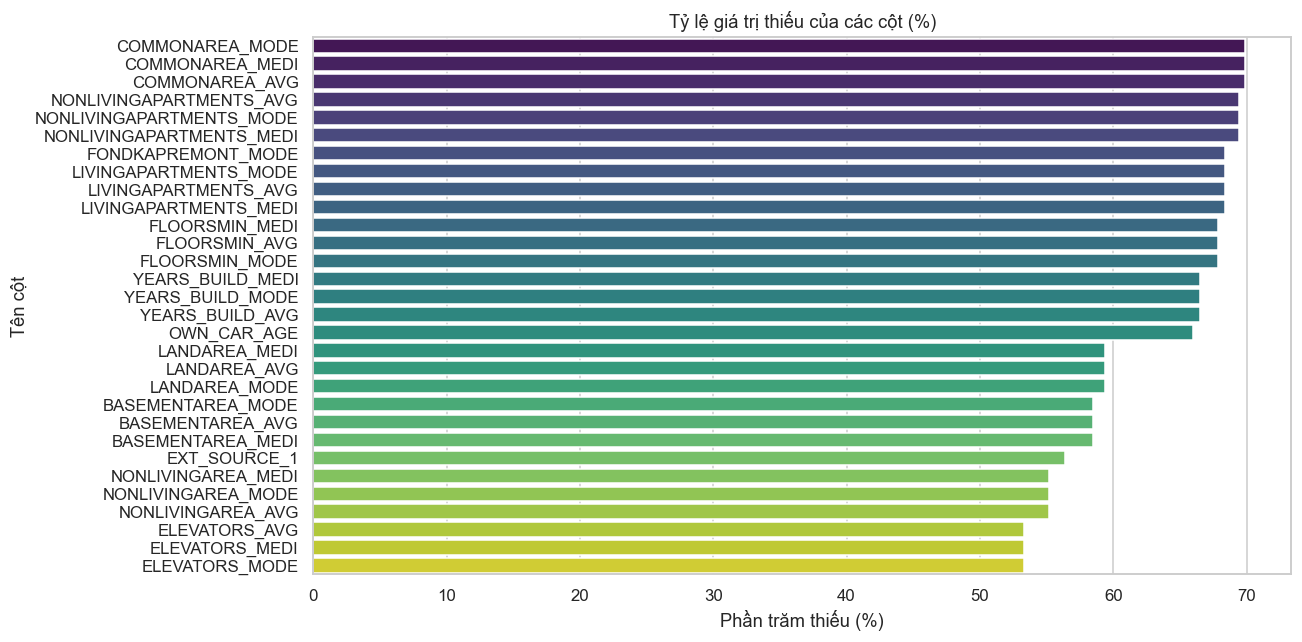

In [8]:
# Tính toán tỷ lệ giá trị thiếu trên tập Train
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100
missing_df = pd.DataFrame({'Total Missing': missing, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Total Missing'] > 0].sort_values(by='Percent', ascending=False)

print("Top 15 cột thiếu nhiều dữ liệu nhất:")
print(missing_df.head(15))

# Vẽ biểu đồ tỷ lệ thiếu của top 30 cột
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.head(30)['Percent'], y=missing_df.head(30).index, palette="viridis")
plt.title("Tỷ lệ giá trị thiếu của các cột (%)")
plt.xlabel("Phần trăm thiếu (%)")
plt.ylabel("Tên cột")
plt.tight_layout()
plt.show()

**Nhận xét:** Nhiều cột thông tin (như chi tiết căn hộ, điểm tín dụng ngoài `EXT_SOURCE_1`, tuổi xe `OWN_CAR_AGE`...) có tỷ lệ khuyết thiếu rất cao (lên tới hơn 50%). 
- Để tránh làm lệch thông tin của mô hình, chúng ta **giữ nguyên giá trị NaN cho các cột số**, cho phép các thuật toán Boosting (LightGBM, XGBoost) tự xử lý tối ưu.
- Đối với các cột phân loại (categorical), chúng ta điền khuyết bằng chuỗi `'Unknown'` để mô hình coi đây là một nhóm thông tin riêng biệt.

In [9]:
# Điền khuyết 'Unknown' cho các cột phân loại
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    train[col] = train[col].fillna('Unknown')
    test[col] = test[col].fillna('Unknown')

print("Số lượng giá trị thiếu trong các cột phân loại sau khi điền 'Unknown':")
print(train[cat_cols].isnull().sum().sum())

Số lượng giá trị thiếu trong các cột phân loại sau khi điền 'Unknown':
0


## 5. Chuẩn hóa kiểu dữ liệu & Loại bỏ cột không sử dụng

Xác định các cột không mang lại giá trị thông tin (phương sai bằng 0) và chuẩn hóa kiểu dữ liệu để tối ưu bộ nhớ RAM.

In [10]:
# 5.1. Loại bỏ các cột có phương sai bằng 0 (chỉ có 1 giá trị duy nhất)
unique_counts = train.nunique()
zero_var_cols = unique_counts[unique_counts == 1].index.tolist()
print("Các cột có phương sai bằng 0 (chỉ chứa 1 giá trị duy nhất):", zero_var_cols)

if zero_var_cols:
    train.drop(columns=zero_var_cols, inplace=True)
    test.drop(columns=zero_var_cols, inplace=True)
    print(f"Đã loại bỏ {len(zero_var_cols)} cột.")

# 5.2. Chuẩn hóa kiểu dữ liệu số nguyên cho ID và TARGET
train['SK_ID_CURR'] = train['SK_ID_CURR'].astype(np.int32)
test['SK_ID_CURR'] = test['SK_ID_CURR'].astype(np.int32)
train['TARGET'] = train['TARGET'].astype(np.int8)

# Tối ưu RAM tổng thể
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

Các cột có phương sai bằng 0 (chỉ chứa 1 giá trị duy nhất): []


RAM giảm từ 329.22 MB xuống 59.24 MB (82.0% reduction)
RAM giảm từ 52.11 MB xuống 9.35 MB (82.1% reduction)


**Nhận xét:** Đã chuẩn hóa thành công các kiểu dữ liệu và tối ưu hóa bộ nhớ RAM. Dữ liệu sau khi nạp đã giảm dung lượng đáng kể nhờ việc downcast hợp lý. Các cột không có sự biến thiên (phương sai bằng 0) nếu có cũng được loại bỏ để giảm nhiễu.

## 6. Xuất dữ liệu đã làm sạch

Lưu trữ các tập dữ liệu đã làm sạch vào thư mục `data/processed/` để phục vụ cho các bước EDA và Feature Engineering tiếp theo.

In [11]:
train_clean_path = DATA_PROCESSED / "application_train_clean.csv"
test_clean_path = DATA_PROCESSED / "application_test_clean.csv"

print("Đang ghi tập Train sạch ra file CSV...")
train.to_csv(train_clean_path, index=False)
print(f"Đã ghi xong tập Train vào: {train_clean_path.resolve()} (Dung lượng: {train_clean_path.stat().st_size / 1024**2:,.2f} MB)")

print("\nĐang ghi tập Test sạch ra file CSV...")
test.to_csv(test_clean_path, index=False)
print(f"Đã ghi xong tập Test vào: {test_clean_path.resolve()} (Dung lượng: {test_clean_path.stat().st_size / 1024**2:,.2f} MB)")

Đang ghi tập Train sạch ra file CSV...


Đã ghi xong tập Train vào: D:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\data\processed\application_train_clean.csv (Dung lượng: 154.39 MB)

Đang ghi tập Test sạch ra file CSV...


Đã ghi xong tập Test vào: D:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\data\processed\application_test_clean.csv (Dung lượng: 24.57 MB)


**Nhận xét:** Quá trình xuất file đã hoàn tất thành công. Dữ liệu sạch đã được lưu trữ dưới định dạng nhẹ hơn tại thư mục `data/processed/` và sẵn sàng cung cấp cho các bước phân tích sâu tiếp theo.

## 7. Tổng kết

Trong notebook này, chúng ta đã thực hiện thành công các bước làm sạch dữ liệu cốt lõi cho bảng đơn chính:
1. **Xử lý Outliers & Anomalies**: Gán giá trị khuyết cho ngày làm việc dị thường `365243` kèm cờ hiệu `DAYS_EMPLOYED_ANOM`. Đổi các trường ngày âm sang số tuyệt đối dương. Giới hạn (cap) cực đại cho thu nhập và số con để giảm nhiễu.
2. **Xử lý Missing Values**: Thống kê tỷ lệ khuyết thiếu, điền khuyết `'Unknown'` cho các trường phân loại và giữ nguyên `NaN` cho trường số để các thuật toán học máy xử lý tự nhiên.
3. **Tối ưu hóa dữ liệu**: Loại bỏ các cột vô giá trị (phương sai bằng 0), downcast kiểu dữ liệu để giảm dung lượng RAM sử dụng.
4. **Xuất kết quả**: Tạo thành công `application_train_clean.csv` và `application_test_clean.csv` tại thư mục `data/processed/`.

**Bước tiếp theo:** Dữ liệu sạch này sẽ được dùng trực tiếp trong notebook [04_eda_visualization.ipynb](file:///c:/duan1/credit-risk-classifier/notebooks/04_eda_visualization.ipynb) và tích hợp vào nguồn nạp của [05_feature_engineering.ipynb](file:///c:/duan1/credit-risk-classifier/notebooks/05_feature_engineering.ipynb) để xây dựng đặc trưng.